## Demonstration: Roses

To demonstrate how ASGRAM works, let's do our best to recreate the following sample autostereogram from the Magic Eye website. (`https://www.magiceye.com/portfolio-items/hearts-and-roses/`)

In [1]:
from PIL import Image

We are provided both the final illusion ...

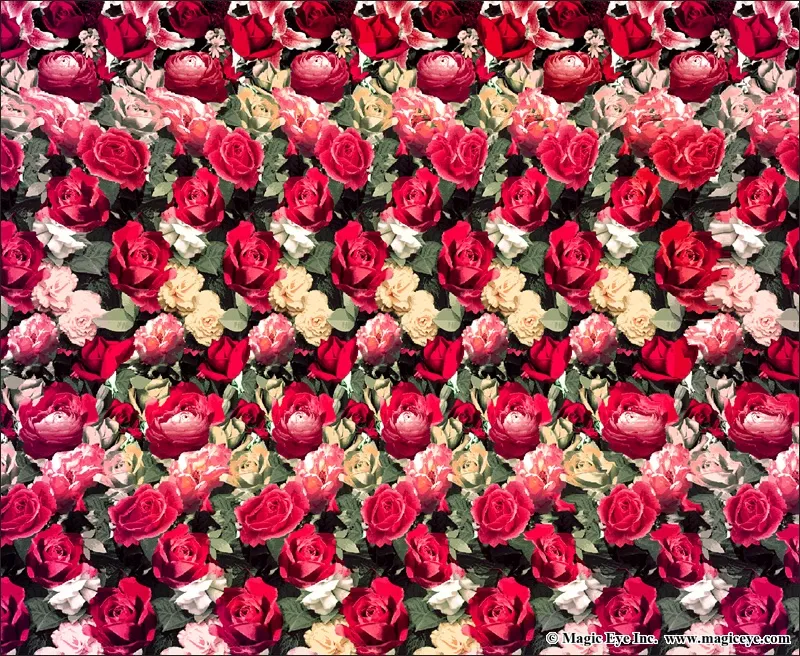

In [23]:
roses = Image.open('images/roses_magic_eye.png')
roses

... as well as the hidden image.

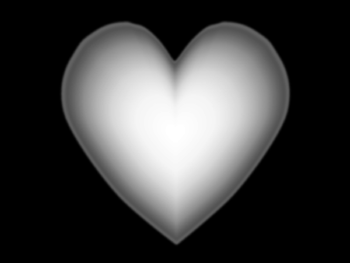

In [4]:
heart = Image.open('images/roses_hidden_image.png')
heart

To create an autostereogram, we simply need to supply the hidden image in pillow format to the `sirds` function in `asgram.art`.

In [5]:
from asgram.art import sirds

SIRDS stands for "Single Image Random Dot Stereogram", the approach described by Thimbleby, Inglis, & Witten (1994).

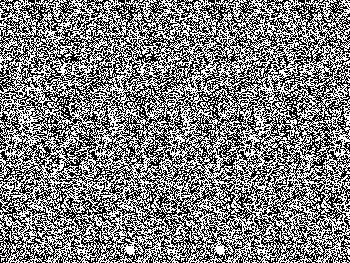

In [6]:
sirds(heart)

You may notice a few difference from this version to the Magic Eye. The dots at the bottom of the screen are convergence dots which may help viewers to see the hidden image. We'll turn those off for now. Let's also increase the image size and add some color using a Matplotlib `colormap`. Finally, to speed things up, we'll increase the number of workers to use for multiprocessing.

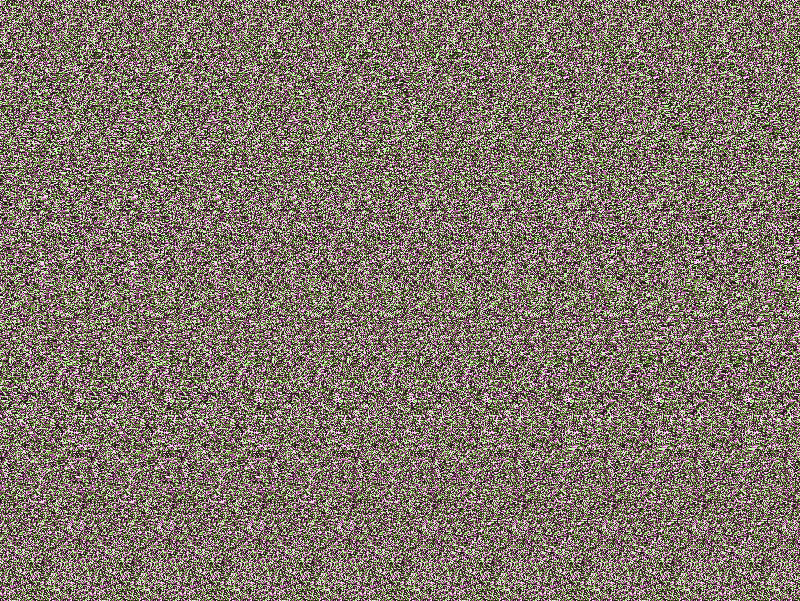

In [24]:
sirds(heart, scale=(16 / 7) ** 2, palette='vanimo', dot_depth=-1, num_jobs=16)

That's a little better! Let's get into the weeds a bit. The depth of field in our autostereogram is more extreme than in the Magic Eye. We can adjust this via the parameter `mu`. We may also wish to adjust the dots per inch.

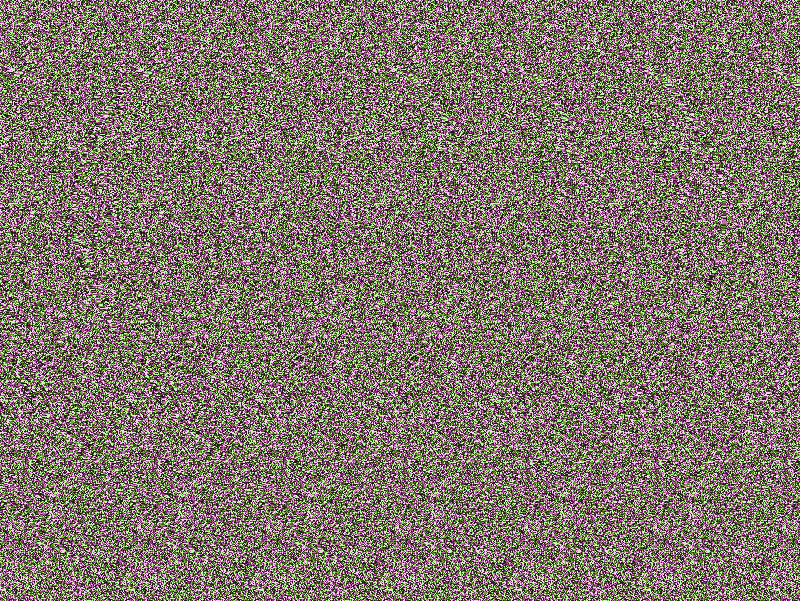

In [183]:
sirds(
    heart,
    mu=0.2, dpi=103,
    scale=(16 / 7) ** 2, palette='vanimo', dot_depth=-1, num_jobs=16
)

Now to move away from the random dot approach, we specify a reference image.

In [60]:
import numpy as np

For simplicity, we treat the base illusion as an array and slice the rightmost part of it.

In [140]:
pattern = Image.fromarray(np.array(roses).T[:, 670:797, :].T)

We take this pattern and repeat it horizontally six times. We also note that the original illusion appears to emanate from the center, so we specify a "middle-out" approach.

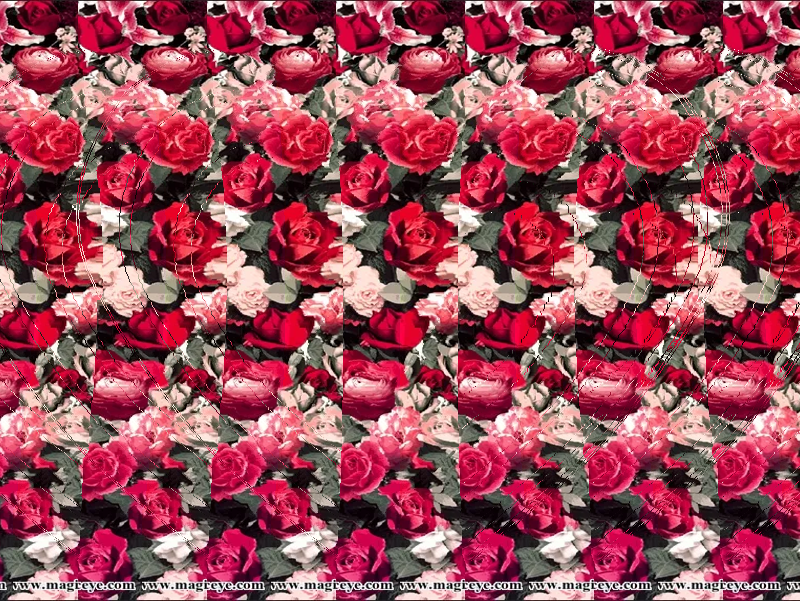

In [182]:
sirds(
    heart, ref_img=pattern, ref_fit='tile=6x1',
    mu=0.2, dpi=103, approach='mo',
    scale=(16 / 7) ** 2, palette='vanimo', dot_depth=-1, num_jobs=16
)

Ta-da! With a better selection of reference image and a little post-processing, the quality of the original Magic Eye is within our reach!